In [5]:
# Importing the libraries

import pandas as pd

# loading the final integrated MEDUSA dataset
df = pd.read_csv('/home/rt334/Downloads/MEDUSA_Master_ULTIMATE.csv', low_memory=False)


# checking a few values for MED001 against the original data
print(df[df.MEDUSA_Subject_ID=='MED001']['Age'].values)               
print(df[df.MEDUSA_Subject_ID=='MED001']['Overall survival (Surgery-to-Death) in days'].values)
print(df[df.MEDUSA_Subject_ID=='MED001']['Histology'].values)


# checking how much methylation clock data is available
print(df['ageAcc.Horvath'].notna().sum())


# number of patients showing BAP1 loss
print((df['Overall BAP1 IHC (1=positive/retained, 0=negative/loss)']==0).sum())


# checking the number of patients with 9p21 loss including MTAP
print((pd.to_numeric(df['DriverLoss 9p21 (CDKN2A,MTAP,IFNA)'],errors='coerce')==1).sum())


# one more check for MED001 using the gender column
print(df[df.MEDUSA_Subject_ID=='MED001']['Gender '].values)


# checking the final number of patients in the merged dataset
print(len(df))


# checking the total number of variables, excluding the subject ID
print(df.shape[1]-1)                               # 1425

[67.]
[875.]
[1.]
56
98
80
[1.]
235
1425


saved table_hermes_stage1_v2.png


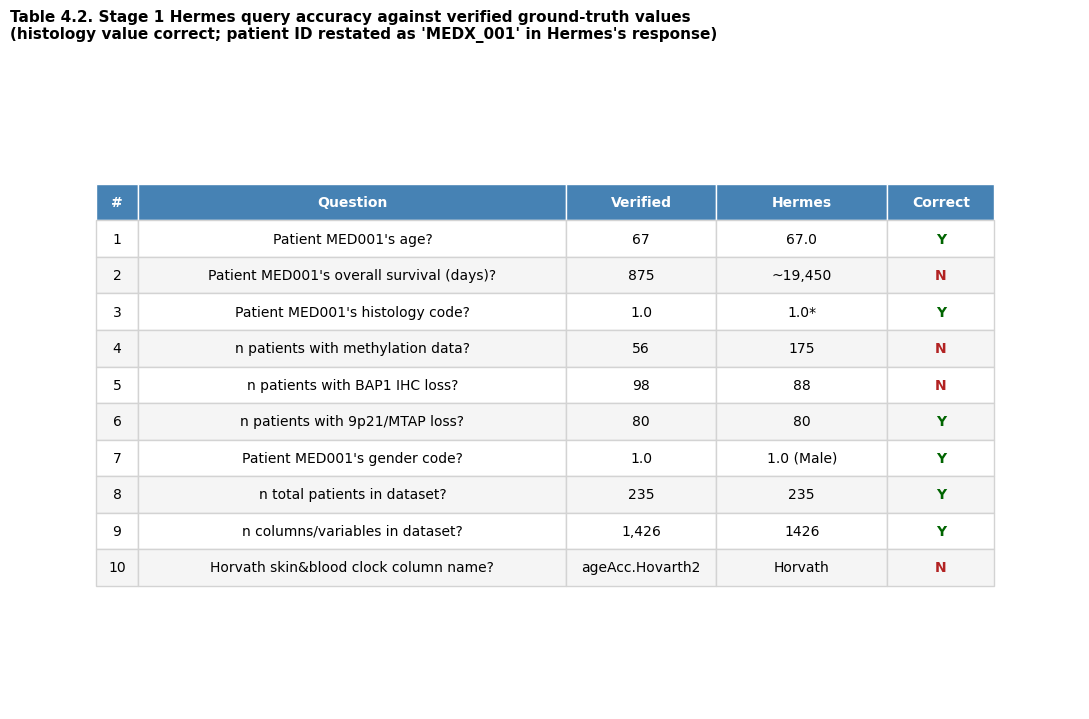

In [6]:
import matplotlib.pyplot as plt

# putting the Stage 1 Hermes checks into a table

data = [
    {'#': 1, 'Question': "Patient MED001's age?", 'Verified': '67', 'Hermes': '67.0', 'Correct': 'Y'},
    {'#': 2, 'Question': "Patient MED001's overall survival (days)?", 'Verified': '875', 'Hermes': '~19,450', 'Correct': 'N'},
    {'#': 3, 'Question': "Patient MED001's histology code?", 'Verified': '1.0', 'Hermes': '1.0*', 'Correct': 'Y'},
    {'#': 4, 'Question': 'n patients with methylation data?', 'Verified': '56', 'Hermes': '175', 'Correct': 'N'},
    {'#': 5, 'Question': 'n patients with BAP1 IHC loss?', 'Verified': '98', 'Hermes': '88', 'Correct': 'N'},
    {'#': 6, 'Question': 'n patients with 9p21/MTAP loss?', 'Verified': '80', 'Hermes': '80', 'Correct': 'Y'},
    {'#': 7, 'Question': "Patient MED001's gender code?", 'Verified': '1.0', 'Hermes': '1.0 (Male)', 'Correct': 'Y'},
    {'#': 8, 'Question': 'n total patients in dataset?', 'Verified': '235', 'Hermes': '235', 'Correct': 'Y'},
    {'#': 9, 'Question': 'n columns/variables in dataset?', 'Verified': '1,426', 'Hermes': '1426', 'Correct': 'Y'},
    {'#': 10, 'Question': 'Horvath skin&blood clock column name?', 'Verified': 'ageAcc.Hovarth2', 'Hermes': 'Horvath', 'Correct': 'N'},
]

df = pd.DataFrame(data)


# setting up the table
fig, ax = plt.subplots(figsize=(11, 0.55 * len(df) + 1.8))
ax.axis('off')

col_labels = list(df.columns)
cell_text = df.astype(str).values.tolist()

table = ax.table(
    cellText=cell_text,
    colLabels=col_labels,
    cellLoc='center',
    loc='center',
    colWidths=[0.04, 0.40, 0.14, 0.16, 0.10]
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.9)


# formatting the header
for col_idx in range(len(col_labels)):
    cell = table[0, col_idx]
    cell.set_facecolor('steelblue')
    cell.set_text_props(color='white', fontweight='bold')
    cell.set_edgecolor('white')


# alternating the row shading and highlighting whether Hermes was correct
correct_idx = col_labels.index('Correct')

for row_idx in range(1, len(df) + 1):
    correct_val = cell_text[row_idx - 1][correct_idx]

    for col_idx in range(len(col_labels)):
        cell = table[row_idx, col_idx]
        cell.set_edgecolor('lightgrey')
        cell.set_facecolor('whitesmoke' if row_idx % 2 == 0 else 'white')

        if col_idx == correct_idx:
            cell.set_text_props(
                fontweight='bold',
                color='darkgreen' if correct_val == 'Y' else 'firebrick'
            )


# adding the table title and saving it for the results section
plt.title(
    "Table 4.2. Stage 1 Hermes query accuracy against verified ground-truth values\n"
    "(histology value correct; patient ID restated as 'MEDX_001' in Hermes's response)",
    fontsize=11,
    fontweight='bold',
    pad=16,
    loc='left'
)

plt.tight_layout()

plt.savefig(
    'table_hermes_stage1_v2.png',
    dpi=300,
    bbox_inches='tight',
    facecolor='white'
)

print('saved table_hermes_stage1_v2.png')